# Email Campaign Optimization using Uplift Modeling & A/B Testing

I came across this dataset while looking for something more interesting to work on than the usual titanic or iris projects. The idea here is pretty simple - a company sent emails to some customers and did not send to others. I want to figure out which customers actually benefit from receiving the email, not just whether the email worked on average.

The dataset is from Kevin Hillstrom and it has 64000 customers split into three groups. One group got a mens email, one got a womens email, and one got nothing. After two weeks they recorded whether each customer visited the site, made a purchase, and how much they spent.

I will go through EDA first, then check if the email actually made a difference using statistical tests, do some power analysis which I recently learned about, then build an uplift model to score individual customers.


## Step 1 - Importing Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

## Step 2 - Loading the Data

Let me load the dataset and take a first look at what we are dealing with.


In [22]:
df = pd.read_csv('Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv')

print("shape:", df.shape)
print()
df.head()


shape: (64000, 12)



,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 8.1 MB


In [24]:
# checking for nulls and basic stats
print("null values in each column:")
print(df.isnull().sum())
print()
print("how many customers in each group:")
print(df['segment'].value_counts())


null values in each column:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

how many customers in each group:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


## Step 3 - Exploratory Data Analysis

Before doing anything else I want to understand the data better. I will look at the distributions of the main columns and also check how visit rate and conversion rate differ across the three groups.


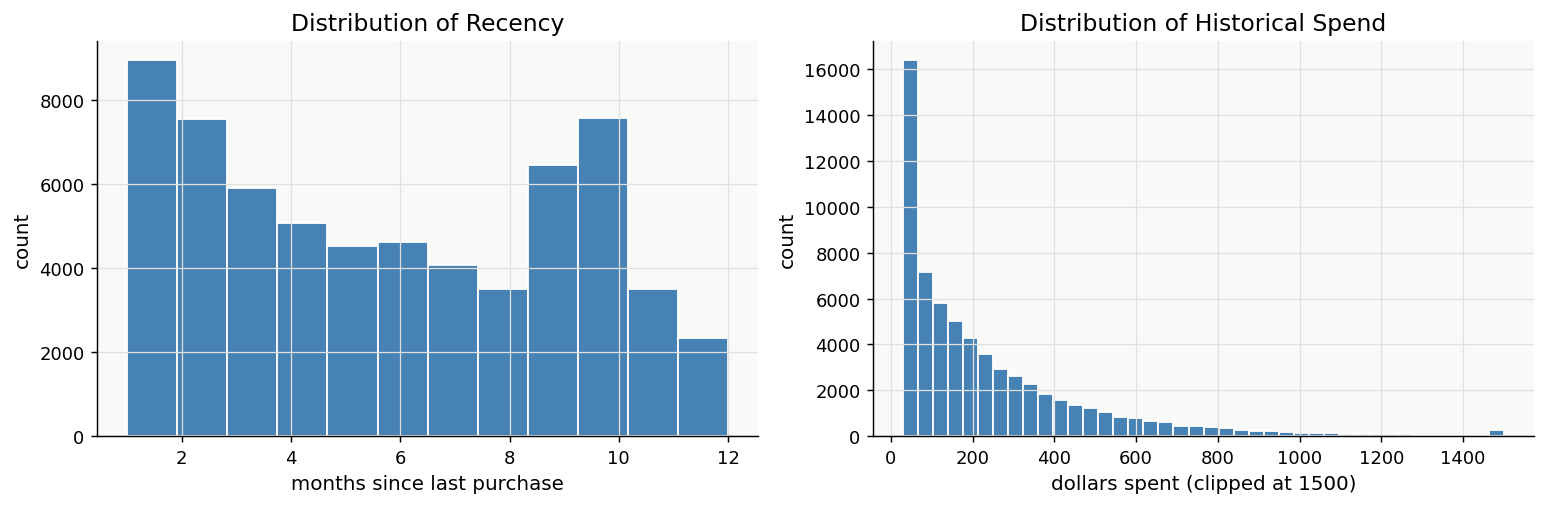

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['recency'], bins=12, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Recency')
axes[0].set_xlabel('months since last purchase')
axes[0].set_ylabel('count')

axes[1].hist(df['history'].clip(upper=1500), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Historical Spend')
axes[1].set_xlabel('dollars spent (clipped at 1500)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()


In [26]:
# visit rate across the three groups - this gives us a first look at whether the emails worked
visit_rates = df.groupby('segment')['visit'].mean() * 100
print("visit rates by segment:")
print(visit_rates.round(2))
print()

conv_rates = df.groupby('segment')['conversion'].mean() * 100
print("conversion rates by segment:")
print(conv_rates.round(2))


visit rates by segment:
segment
Mens E-Mail      18.28
No E-Mail        10.62
Womens E-Mail    15.14
Name: visit, dtype: float64

conversion rates by segment:
segment
Mens E-Mail      1.25
No E-Mail        0.57
Womens E-Mail    0.88
Name: conversion, dtype: float64


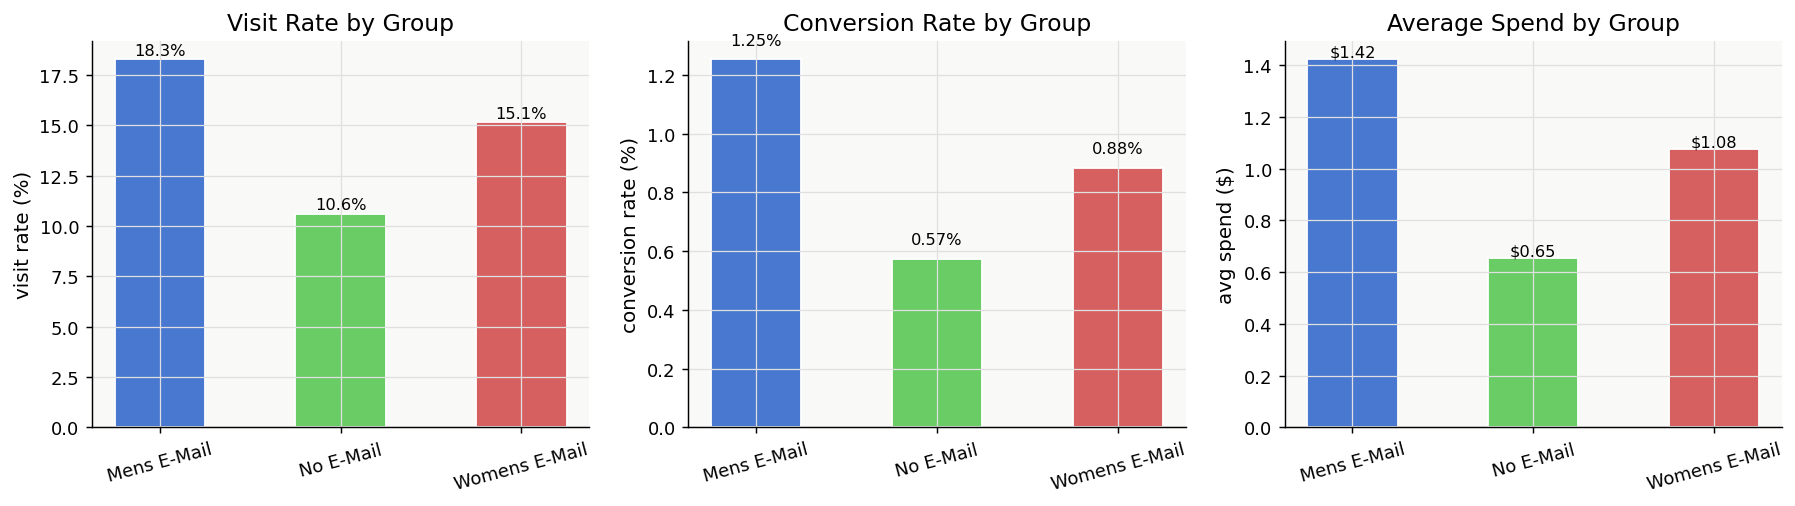

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

groups = df['segment'].unique()
colors = ['#4878cf', '#6acc65', '#d65f5f']

# visit rate
vr = df.groupby('segment')['visit'].mean() * 100
axes[0].bar(vr.index, vr.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Visit Rate by Group')
axes[0].set_ylabel('visit rate (%)')
axes[0].set_xticklabels(vr.index, rotation=15)
for i, v in enumerate(vr.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# conversion rate
cr = df.groupby('segment')['conversion'].mean() * 100
axes[1].bar(cr.index, cr.values, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Conversion Rate by Group')
axes[1].set_ylabel('conversion rate (%)')
axes[1].set_xticklabels(cr.index, rotation=15)
for i, v in enumerate(cr.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

# avg spend
sp = df.groupby('segment')['spend'].mean()
axes[2].bar(sp.index, sp.values, color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Average Spend by Group')
axes[2].set_ylabel('avg spend ($)')
axes[2].set_xticklabels(sp.index, rotation=15)
for i, v in enumerate(sp.values):
    axes[2].text(i, v + 0.01, f'${v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


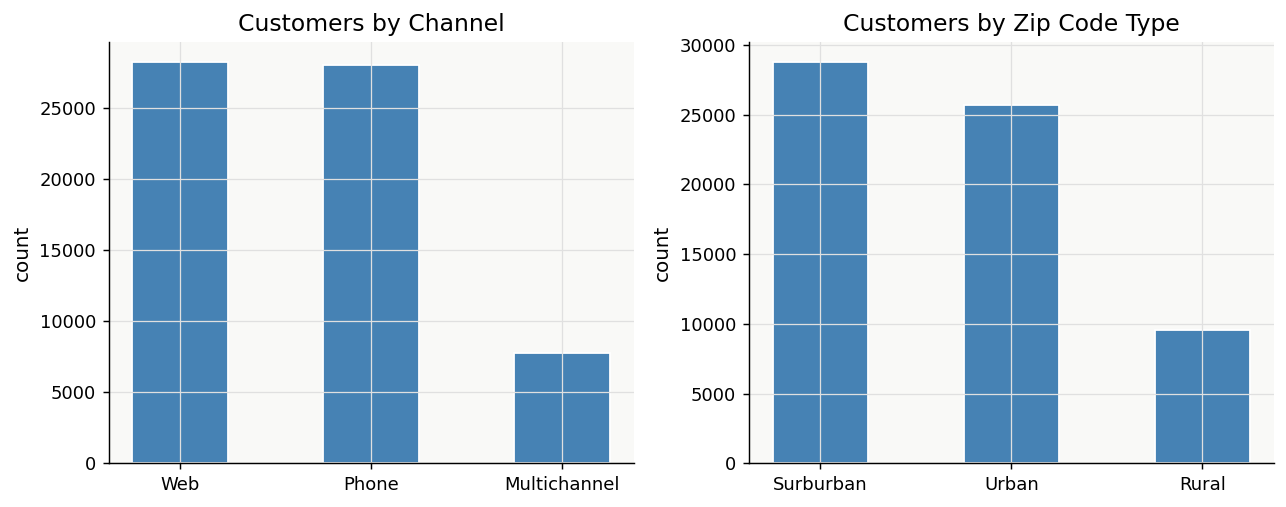

In [28]:
# also want to see how channel and zip code break down
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ch = df['channel'].value_counts()
axes[0].bar(ch.index, ch.values, color='steelblue', edgecolor='white', width=0.5)
axes[0].set_title('Customers by Channel')
axes[0].set_ylabel('count')

zp = df['zip_code'].value_counts()
axes[1].bar(zp.index, zp.values, color='steelblue', edgecolor='white', width=0.5)
axes[1].set_title('Customers by Zip Code Type')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()


## Step 4 - Feature Engineering

The categorical columns need to be converted to numbers before I can use them in a model. I also want to create a couple of extra features that might help.


In [29]:
df_model = df.copy()

# encoding the categorical columns manually using a dictionary map
# I could use LabelEncoder but doing it manually gives me more control over the order

history_map = {
    '1) $0 - $100': 0,
    '2) $100 - $200': 1,
    '3) $200 - $350': 2,
    '4) $350 - $500': 3,
    '5) $500 - $750': 4,
    '6) $750 - $1,000': 5,
    '7) $1,000 +': 6
}

zip_map = {
    'Rural': 0,
    'Surburban': 1,
    'Urban': 2
}

channel_map = {
    'Phone': 0,
    'Web': 1,
    'Multichannel': 2
}

df_model['hist_enc']    = df_model['history_segment'].map(history_map)
df_model['zip_enc']     = df_model['zip_code'].map(zip_map)
df_model['channel_enc'] = df_model['channel'].map(channel_map)

# creating a few extra features
# customers who bought from both categories might respond differently to email
df_model['bought_both'] = ((df_model['mens'] == 1) & (df_model['womens'] == 1)).astype(int)

# combining recency and history into one feature
df_model['recency_history'] = df_model['recency'] * np.log1p(df_model['history'])

# flag for high value customers
df_model['high_value'] = (df_model['hist_enc'] >= 4).astype(int)

FEATURES = [
    'recency', 'history', 'mens', 'womens',
    'zip_enc', 'newbie', 'channel_enc', 'hist_enc',
    'bought_both', 'recency_history', 'high_value'
]

print("features we will use:", FEATURES)
print("total features:", len(FEATURES))
print()
df_model[FEATURES].describe().round(2)


features we will use: ['recency', 'history', 'mens', 'womens', 'zip_enc', 'newbie', 'channel_enc', 'hist_enc', 'bought_both', 'recency_history', 'high_value']
total features: 11



,recency,history,mens,womens,zip_enc,newbie,channel_enc,hist_enc,bought_both,recency_history,high_value
count,64000.00,64000.00,64000.00,64000.00,64000.00,64000.0,64000.00,64000.00,64000.0,64000.00,64000.00
mean,5.76,242.09,0.55,0.55,1.25,0.5,0.68,1.48,0.1,28.04,0.13
std,3.51,256.16,0.50,0.50,0.70,0.5,0.68,1.54,0.3,17.44,0.33
min,1.00,29.99,0.00,0.00,0.00,0.0,0.00,0.00,0.0,3.43,0.00
25%,2.00,64.66,0.00,0.00,1.00,0.0,0.00,0.00,0.0,12.32,0.00
50%,6.00,158.11,1.00,1.00,1.00,1.0,1.00,1.00,0.0,26.36,0.00
75%,9.00,325.66,1.00,1.00,2.00,1.0,1.00,2.00,0.0,41.20,0.00
max,12.00,3345.93,1.00,1.00,2.00,1.0,2.00,6.00,1.0,87.30,1.00


## Step 5 - A/B Test Analysis

Now I want to check whether the difference in visit rates between the email groups and the control group is statistically significant or just random chance.

I will use a two sample t-test for this. The null hypothesis is that there is no difference in visit rates between the groups. If the p value is below 0.05 I will reject the null hypothesis and conclude that the email had a real effect.

I will also calculate Cohen's d to understand the practical significance, not just the statistical significance. A result can be statistically significant but practically meaningless if the actual difference is tiny.


In [30]:
control = df_model[df_model['segment'] == 'No E-Mail']
womens_group = df_model[df_model['segment'] == 'Womens E-Mail']
mens_group = df_model[df_model['segment'] == 'Mens E-Mail']

print("group sizes:")
print("control:", len(control))
print("womens email:", len(womens_group))
print("mens email:", len(mens_group))


group sizes:
control: 21306
womens email: 21387
mens email: 21307


In [31]:
def run_ab_test(treatment_group, control_group, metric, group_name):
    t_val = treatment_group[metric].mean()
    c_val = control_group[metric].mean()

    difference = t_val - c_val
    relative_change = (difference / c_val) * 100

    t_stat, p_value = stats.ttest_ind(treatment_group[metric], control_group[metric])

    # cohen's d - measures practical effect size
    pooled_std = np.sqrt((treatment_group[metric].std()**2 + control_group[metric].std()**2) / 2)
    cohens_d = difference / pooled_std if pooled_std > 0 else 0

    # 95% confidence interval for the difference
    se = np.sqrt(
        treatment_group[metric].var() / len(treatment_group) +
        control_group[metric].var() / len(control_group)
    )
    ci_lower = difference - 1.96 * se
    ci_upper = difference + 1.96 * se

    return {
        'group': group_name,
        'metric': metric,
        'control_mean': round(c_val, 4),
        'treatment_mean': round(t_val, 4),
        'difference': round(difference, 4),
        'relative_change_%': round(relative_change, 2),
        'p_value': round(p_value, 6),
        'cohens_d': round(cohens_d, 4),
        'ci_95': f'[{ci_lower:.4f}, {ci_upper:.4f}]',
        'significant': 'yes' if p_value < 0.05 else 'no'
    }

results = []
for group, name in [(womens_group, 'womens email'), (mens_group, 'mens email')]:
    for metric in ['visit', 'conversion', 'spend']:
        results.append(run_ab_test(group, control, metric, name))

results_df = pd.DataFrame(results)
results_df


,group,metric,control_mean,treatment_mean,difference,relative_change_%,p_value,cohens_d,ci_95,significant
0,womens email,visit,0.1062,0.1514,0.0452,42.61,0.000000,0.1353,"[0.0389, 0.0516]",yes
1,womens email,conversion,0.0057,0.0088,0.0031,54.33,0.000157,0.0366,"[0.0015, 0.0047]",yes
2,womens email,spend,0.6528,1.0772,0.4244,65.02,0.001136,0.0315,"[0.1690, 0.6799]",yes
3,mens email,visit,0.1062,0.1828,0.0766,72.14,0.000000,0.2192,"[0.0700, 0.0832]",yes
4,mens email,conversion,0.0057,0.0125,0.0068,118.84,0.000000,0.0716,"[0.0050, 0.0086]",yes
5,mens email,spend,0.6528,1.4226,0.7698,117.93,0.000000,0.0514,"[0.4851, 1.0545]",yes


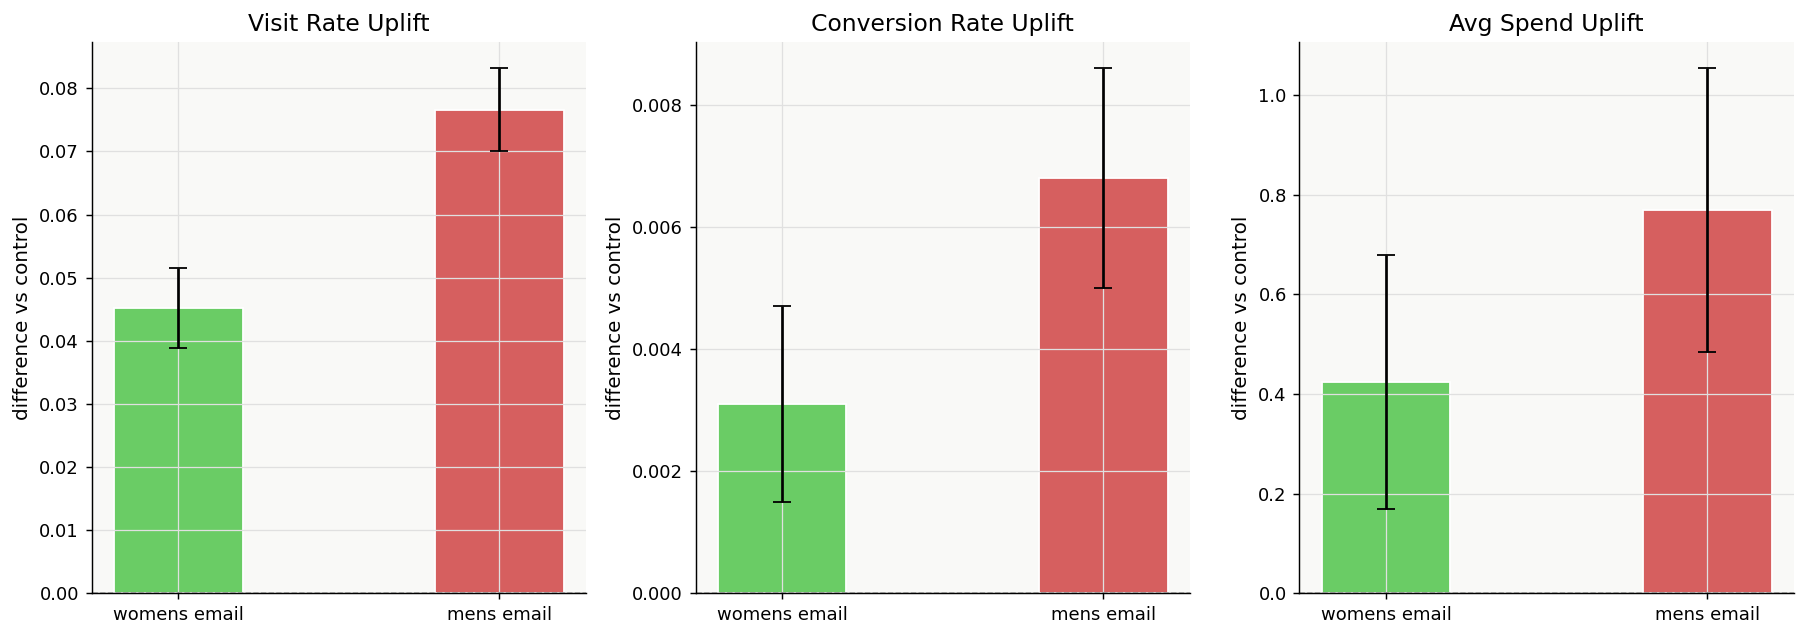

both email campaigns show statistically significant uplift across all three metrics


In [32]:
# plotting the uplift with confidence intervals

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['visit', 'conversion', 'spend']
titles = ['Visit Rate Uplift', 'Conversion Rate Uplift', 'Avg Spend Uplift']

for ax, metric, title in zip(axes, metrics, titles):
    sub = results_df[results_df['metric'] == metric]
    colors = ['#6acc65', '#d65f5f']

    bars = ax.bar(sub['group'], sub['difference'], color=colors, width=0.4, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('difference vs control')

    # adding the ci error bars
    ci_errors = []
    for _, row in sub.iterrows():
        lo, hi = [float(x) for x in row['ci_95'].strip('[]').split(',')]
        ci_errors.append([row['difference'] - lo, hi - row['difference']])
    ci_errors = np.array(ci_errors).T

    ax.errorbar(sub['group'], sub['difference'], yerr=ci_errors,
                fmt='none', color='black', capsize=5, linewidth=1.5)

plt.tight_layout()
plt.show()

print("both email campaigns show statistically significant uplift across all three metrics")


## Step 6 - Power Analysis

This is something I recently learned about. Power analysis is used to figure out how many samples you need before running an experiment to make sure your results will be reliable.

The idea is that there are four things connected to each other:
- sample size
- the minimum effect size you want to be able to detect
- significance level (alpha), usually 0.05
- statistical power, usually 0.8 which means 80% chance of detecting a real effect

If you fix three of them you can calculate the fourth. Here I will calculate how many users were actually needed for this experiment and compare it to how many we had.


In [33]:
def get_required_sample_size(p1, p2, alpha=0.05, power=0.8):
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    p_avg = (p1 + p2) / 2
    effect = abs(p2 - p1)
    if effect == 0:
        return float('inf')
    n = (z_alpha + z_beta)**2 * 2 * p_avg * (1 - p_avg) / effect**2
    return int(np.ceil(n))

ctrl_visit_rate = control['visit'].mean()
mens_visit_rate = mens_group['visit'].mean()
womens_visit_rate = womens_group['visit'].mean()

required_for_mens = get_required_sample_size(ctrl_visit_rate, mens_visit_rate)
required_for_womens = get_required_sample_size(ctrl_visit_rate, womens_visit_rate)
actual_per_group = len(control)

print(f"control visit rate:     {ctrl_visit_rate:.4f}")
print(f"mens email visit rate:  {mens_visit_rate:.4f}")
print(f"womens email visit rate:{womens_visit_rate:.4f}")
print()
print(f"required sample size for mens vs control:   {required_for_mens}")
print(f"required sample size for womens vs control: {required_for_womens}")
print(f"actual sample size per group:               {actual_per_group}")
print()
print(f"the experiment had {actual_per_group // required_for_mens}x more data than needed for mens")
print(f"the experiment had {actual_per_group // required_for_womens}x more data than needed for womens")


control visit rate:     0.1062
mens email visit rate:  0.1828
womens email visit rate:0.1514

required sample size for mens vs control:   331
required sample size for womens vs control: 861
actual sample size per group:               21306

the experiment had 64x more data than needed for mens
the experiment had 24x more data than needed for womens


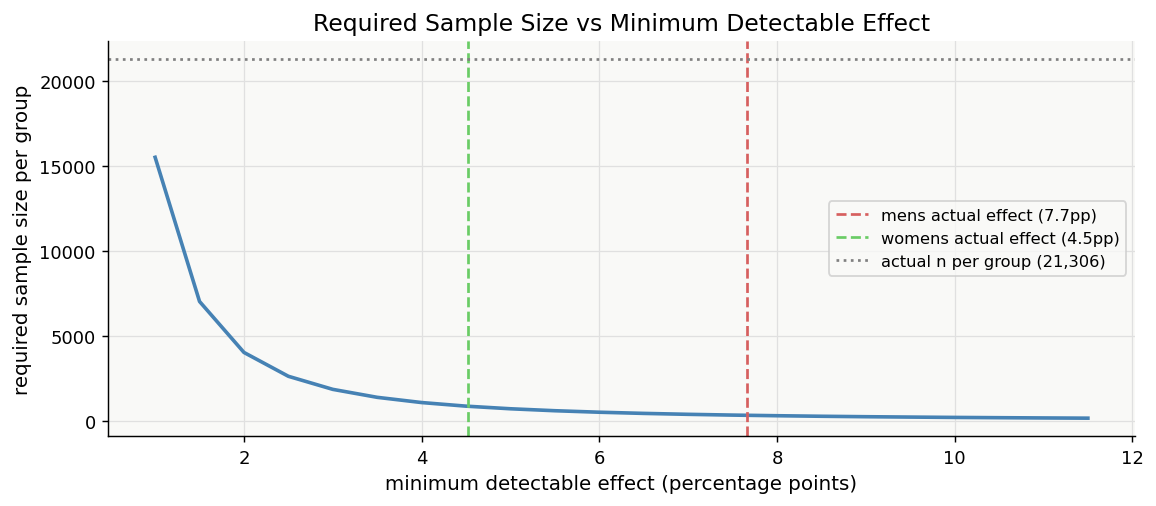

In [34]:
# plotting how sample size needed changes as the minimum detectable effect changes

mde_values = np.arange(0.01, 0.12, 0.005)
required_n = [get_required_sample_size(ctrl_visit_rate, ctrl_visit_rate + mde) for mde in mde_values]

plt.figure(figsize=(9, 4))
plt.plot(mde_values * 100, required_n, color='steelblue', linewidth=2)
plt.axvline((mens_visit_rate - ctrl_visit_rate) * 100, color='#d65f5f', linestyle='--',
            label=f'mens actual effect ({(mens_visit_rate - ctrl_visit_rate)*100:.1f}pp)')
plt.axvline((womens_visit_rate - ctrl_visit_rate) * 100, color='#6acc65', linestyle='--',
            label=f'womens actual effect ({(womens_visit_rate - ctrl_visit_rate)*100:.1f}pp)')
plt.axhline(actual_per_group, color='gray', linestyle=':', label=f'actual n per group ({actual_per_group:,})')
plt.xlabel('minimum detectable effect (percentage points)')
plt.ylabel('required sample size per group')
plt.title('Required Sample Size vs Minimum Detectable Effect')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Step 7 - Uplift Modelling

This is the main part of the project. Instead of just asking whether the email worked on average, I want to score each individual customer to find out who is most likely to respond to the email specifically because of the email, not for other reasons.

The approach I am using is called T-Learner. The idea is to train separate models on each group. One model learns what predicts a visit when no email is sent. Another learns what predicts a visit when the mens email is sent. The uplift for a customer is just the difference between the two predictions. A high uplift means that customer is likely to visit because of the email.

I tried two approaches and will compare them at the end.


In [35]:
# splitting the data by segment for the T-Learner

scaler = StandardScaler()

X_control = scaler.fit_transform(control[FEATURES])
X_mens = scaler.transform(mens_group[FEATURES])
X_womens = scaler.transform(womens_group[FEATURES])
X_all = scaler.transform(df_model[FEATURES])

y_control = control['visit'].values
y_mens = mens_group['visit'].values
y_womens = womens_group['visit'].values

print("X_control shape:", X_control.shape)
print("X_mens shape:", X_mens.shape)
print("X_womens shape:", X_womens.shape)


X_control shape: (21306, 11)
X_mens shape: (21307, 11)
X_womens shape: (21387, 11)


In [36]:
# training separate gradient boosting models for each group
# I chose gradient boosting because it handles non linear relationships well
# and does not need a lot of feature engineering compared to linear models

model_control = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_mens = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_womens = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

model_control.fit(X_control, y_control)
model_mens.fit(X_mens, y_mens)
model_womens.fit(X_womens, y_womens)

print("all three models trained")


all three models trained


In [37]:
# calculating uplift scores for every customer in the dataset
# uplift = predicted probability with email - predicted probability without email

p_no_email = model_control.predict_proba(X_all)[:, 1]
p_mens_email = model_mens.predict_proba(X_all)[:, 1]
p_womens_email = model_womens.predict_proba(X_all)[:, 1]

df_model['uplift_mens'] = p_mens_email - p_no_email
df_model['uplift_womens'] = p_womens_email - p_no_email

print("average uplift for mens email:", df_model['uplift_mens'].mean().round(4))
print("average uplift for womens email:", df_model['uplift_womens'].mean().round(4))
print()
print("uplift score distribution:")
df_model[['uplift_mens', 'uplift_womens']].describe().round(4)


average uplift for mens email: 0.0762
average uplift for womens email: 0.0453

uplift score distribution:


,uplift_mens,uplift_womens
count,64000.0000,64000.0000
mean,0.0762,0.0453
std,0.0421,0.0474
min,-0.7011,-0.6204
25%,0.0586,0.0159
50%,0.0712,0.0476
75%,0.0859,0.0749
max,0.6109,0.6968


In [38]:
# also trying S-Learner as a comparison
# here I train one model on all the data and include treatment as a feature

df_model['treatment'] = df_model['segment'].map({
    'No E-Mail': 0,
    'Mens E-Mail': 1,
    'Womens E-Mail': 2
})

features_with_treatment = FEATURES + ['treatment']

scaler2 = StandardScaler()
X_all_with_treatment = scaler2.fit_transform(df_model[features_with_treatment])

model_single = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_single.fit(X_all_with_treatment, df_model['visit'])

# to get uplift I predict twice - once as control, once as treated
X_as_control = df_model[FEATURES].copy()
X_as_control['treatment'] = 0
X_as_treated = df_model[FEATURES].copy()
X_as_treated['treatment'] = 1

p_ctrl_s = model_single.predict_proba(scaler2.transform(X_as_control))[:, 1]
p_mens_s = model_single.predict_proba(scaler2.transform(X_as_treated))[:, 1]

df_model['uplift_mens_slearner'] = p_mens_s - p_ctrl_s

print("S-Learner average uplift for mens email:", df_model['uplift_mens_slearner'].mean().round(4))


S-Learner average uplift for mens email: 0.0698


## Step 8 - Model Evaluation

For the response models I will check AUC on a held out test set. For comparing the uplift models I will use a Qini curve. The Qini curve is the standard way to evaluate uplift models because you cannot use normal metrics like AUC when you are trying to measure a causal effect.

The idea behind the Qini curve is that you sort all customers by their predicted uplift score from highest to lowest, then check how many incremental visits you capture as you target more and more customers. A good uplift model should capture most of the incremental visits by targeting only a small fraction of customers.


In [39]:
# checking AUC for the three response models

def check_auc(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    m = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m.fit(X_train, y_train)
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    return auc, fpr, tpr

auc_ctrl, fpr_ctrl, tpr_ctrl = check_auc(X_control, y_control)
auc_mens, fpr_mens, tpr_mens = check_auc(X_mens, y_mens)
auc_wom, fpr_wom, tpr_wom = check_auc(X_womens, y_womens)

print(f"AUC - control model:  {auc_ctrl:.4f}")
print(f"AUC - mens model:     {auc_mens:.4f}")
print(f"AUC - womens model:   {auc_wom:.4f}")
print()
print("the AUC is around 0.63 to 0.66 for all three which is not super high")
print("but behavioral data is naturally noisy so this is expected")


AUC - control model:  0.6635
AUC - mens model:     0.6140
AUC - womens model:   0.6126

the AUC is around 0.63 to 0.66 for all three which is not super high
but behavioral data is naturally noisy so this is expected


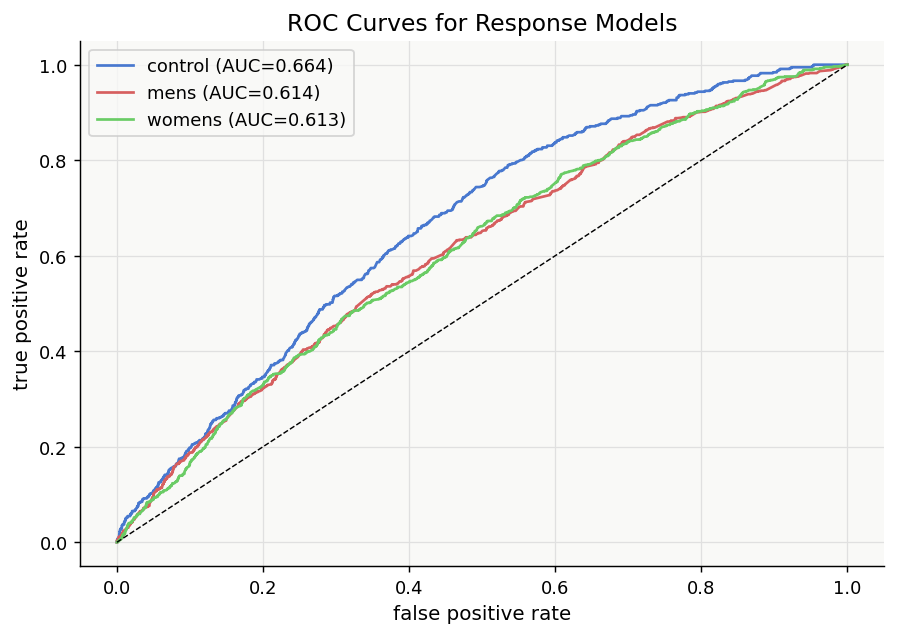

In [40]:
plt.figure(figsize=(7, 5))
plt.plot(fpr_ctrl, tpr_ctrl, label=f'control (AUC={auc_ctrl:.3f})', color='#4878cf')
plt.plot(fpr_mens, tpr_mens, label=f'mens (AUC={auc_mens:.3f})', color='#d65f5f')
plt.plot(fpr_wom, tpr_wom, label=f'womens (AUC={auc_wom:.3f})', color='#6acc65')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curves for Response Models')
plt.legend()
plt.tight_layout()
plt.show()


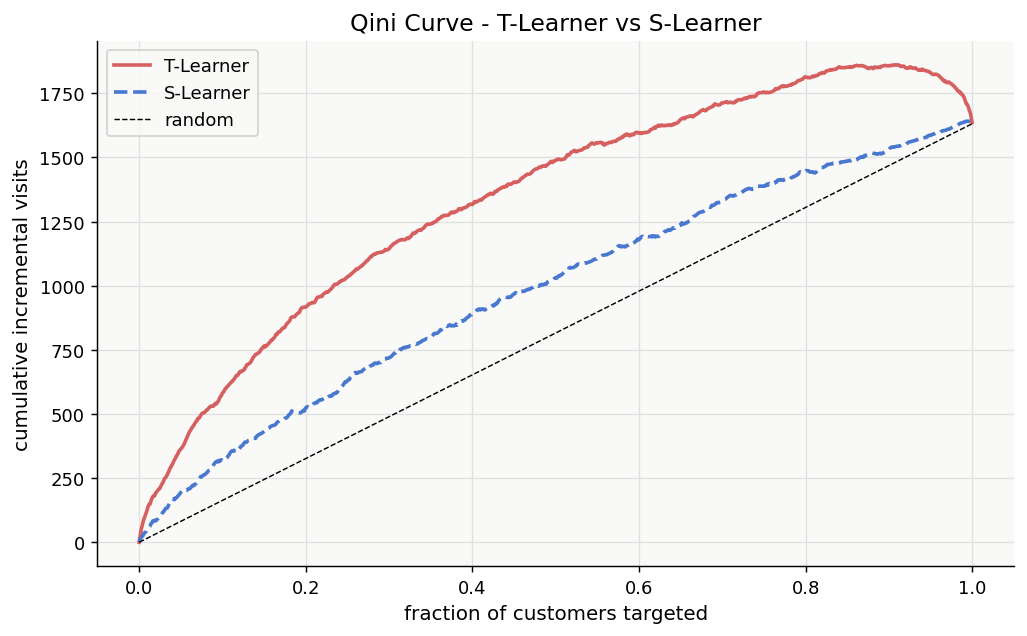

AUUC T-Learner: 1339.40
AUUC S-Learner: 982.14

T-Learner performs better so I will use that for scoring customers


In [43]:
# Qini curve for the uplift models
# comparing T-Learner vs S-Learner

def qini_curve(df_input, uplift_col, outcome='visit', treatment_col='is_treatment'):
    df_sorted = df_input.sort_values(uplift_col, ascending=False).reset_index(drop=True)
    n = len(df_sorted)
    incremental = []
    for k in range(1, n + 1):
        top = df_sorted.iloc[:k]
        nt = top[treatment_col].sum()
        nc = k - nt
        gain_t = top[top[treatment_col] == 1][outcome].sum()
        gain_c = top[top[treatment_col] == 0][outcome].sum()
        if nt > 0 and nc > 0:
            inc = gain_t - gain_c * (nt / nc)
        elif nt > 0:
            inc = gain_t
        else:
            inc = 0
        incremental.append(inc)
    fractions = np.linspace(0, 1, n)
    return fractions, np.array(incremental)

df_qini = df_model[df_model['segment'].isin(['No E-Mail', 'Mens E-Mail'])].copy()
df_qini['is_treatment'] = (df_qini['segment'] == 'Mens E-Mail').astype(int)

frac_t, qini_t = qini_curve(df_qini, 'uplift_mens')
frac_s, qini_s = qini_curve(df_qini, 'uplift_mens_slearner')

plt.figure(figsize=(8, 5))
plt.plot(frac_t[::50], qini_t[::50], label='T-Learner', color='#d65f5f', linewidth=2)
plt.plot(frac_s[::50], qini_s[::50], label='S-Learner', color='#4878cf', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, qini_t[-1]], 'k--', linewidth=0.8, label='random')
plt.xlabel('fraction of customers targeted')
plt.ylabel('cumulative incremental visits')
plt.title('Qini Curve - T-Learner vs S-Learner')
plt.legend()
plt.tight_layout()
plt.show()

auuc_t = np.trapz(qini_t, frac_t)
auuc_s = np.trapz(qini_s, frac_s)
print(f"AUUC T-Learner: {auuc_t:.2f}")
print(f"AUUC S-Learner: {auuc_s:.2f}")
print()
print("T-Learner performs better so I will use that for scoring customers")


## Step 9 - Feature Importance

I want to understand which features the model is using the most. Gradient Boosting gives us feature importances directly which makes this easy.


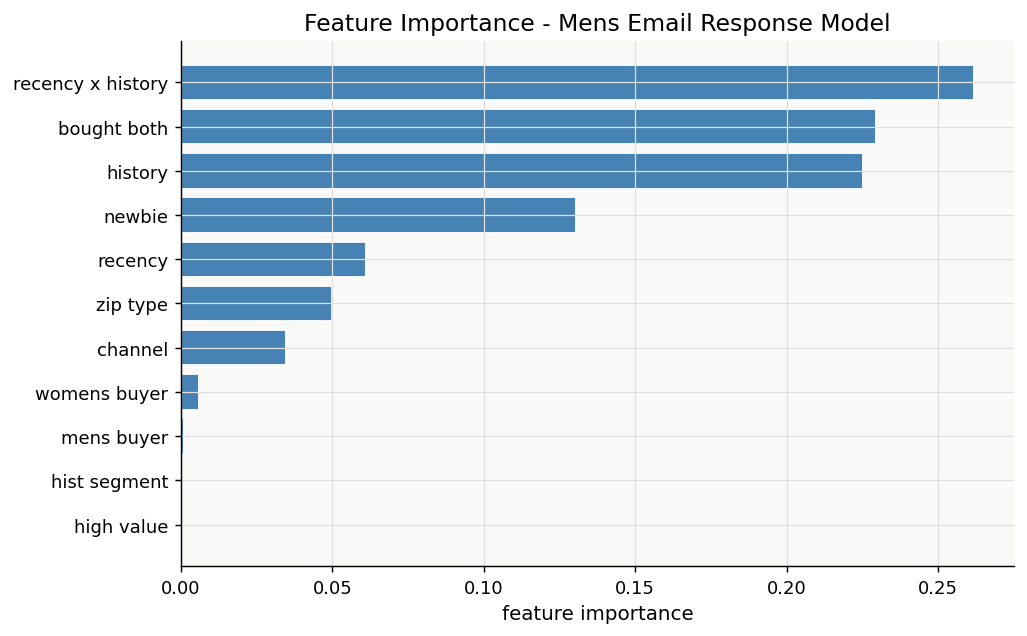

most important features:
          feature  importance
recency x history    0.261991
      bought both    0.229567
          history    0.225137
           newbie    0.130333
          recency    0.061087


In [44]:
feature_labels = [
    'recency', 'history', 'mens buyer', 'womens buyer',
    'zip type', 'newbie', 'channel', 'hist segment',
    'bought both', 'recency x history', 'high value'
]

importances = model_mens.feature_importances_
imp_df = pd.DataFrame({'feature': feature_labels, 'importance': importances})
imp_df = imp_df.sort_values('importance')

plt.figure(figsize=(8, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue', edgecolor='white')
plt.xlabel('feature importance')
plt.title('Feature Importance - Mens Email Response Model')
plt.tight_layout()
plt.show()

print("most important features:")
print(imp_df.sort_values('importance', ascending=False).head(5).to_string(index=False))


## Step 10 - Uplift Segmentation

Now I want to check whether the uplift model is actually ranking customers correctly. I will divide all customers into 10 groups (deciles) based on their predicted uplift score and then check the actual observed visit rates in each group. If the model is working well the top deciles should show higher actual uplift.

I will also look at the characteristics of high uplift vs low uplift customers to understand who is most likely to respond to the email.


In [45]:
df_model['uplift_decile'] = pd.qcut(df_model['uplift_mens'], q=10, labels=False)

# checking actual observed uplift in each decile using only the mens and control groups
df_decile = df_model[df_model['segment'].isin(['No E-Mail', 'Mens E-Mail'])].copy()

decile_rates = df_decile.groupby(['uplift_decile', 'segment'])['visit'].mean().unstack()
decile_rates['actual_uplift'] = decile_rates['Mens E-Mail'] - decile_rates['No E-Mail']

print("actual observed uplift by predicted uplift decile:")
print(decile_rates.round(4))


actual observed uplift by predicted uplift decile:
segment        Mens E-Mail  No E-Mail  actual_uplift
uplift_decile                                       
0                   0.1180     0.2273        -0.1093
1                   0.1196     0.0997         0.0200
2                   0.1220     0.0727         0.0493
3                   0.1334     0.0812         0.0522
4                   0.1567     0.1028         0.0540
5                   0.1739     0.0957         0.0783
6                   0.1727     0.0881         0.0846
7                   0.1885     0.0845         0.1040
8                   0.2560     0.0970         0.1590
9                   0.3847     0.1161         0.2686


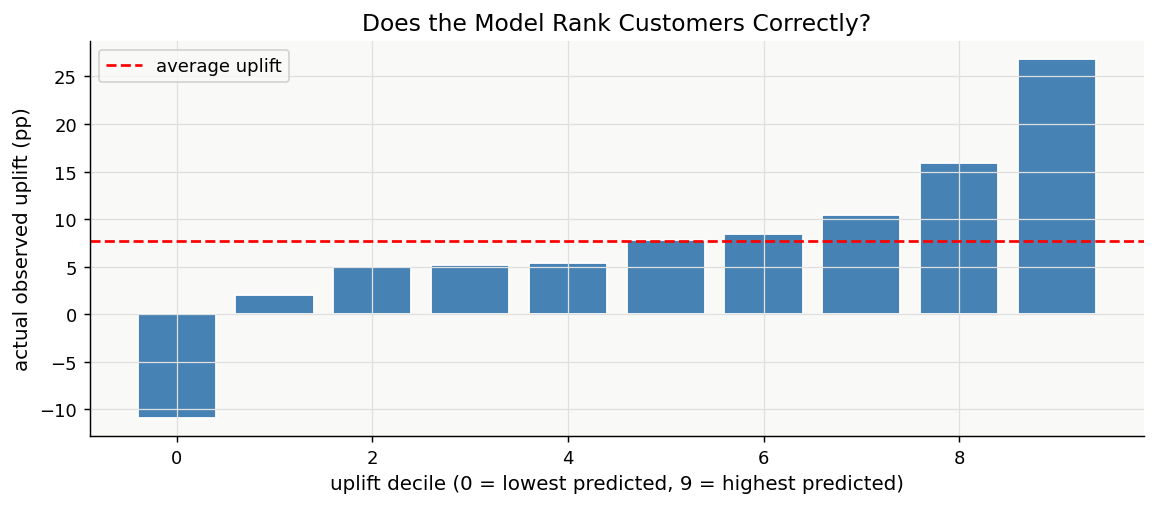

the top decile has higher actual uplift than the bottom decile
this confirms the model is ranking customers in the right direction


In [46]:
plt.figure(figsize=(9, 4))
plt.bar(decile_rates.index, decile_rates['actual_uplift'] * 100,
        color='steelblue', edgecolor='white')
plt.axhline(df_qini[df_qini['is_treatment'] == 1]['visit'].mean() * 100 -
            df_qini[df_qini['is_treatment'] == 0]['visit'].mean() * 100,
            color='red', linestyle='--', label='average uplift')
plt.xlabel('uplift decile (0 = lowest predicted, 9 = highest predicted)')
plt.ylabel('actual observed uplift (pp)')
plt.title('Does the Model Rank Customers Correctly?')
plt.legend()
plt.tight_layout()
plt.show()

print("the top decile has higher actual uplift than the bottom decile")
print("this confirms the model is ranking customers in the right direction")


In [47]:
# profiling high uplift vs low uplift customers

top_20 = df_model[df_model['uplift_mens'] >= df_model['uplift_mens'].quantile(0.8)]
bottom_20 = df_model[df_model['uplift_mens'] <= df_model['uplift_mens'].quantile(0.2)]

compare_cols = ['recency', 'history', 'mens', 'womens', 'newbie', 'bought_both']

profile = pd.DataFrame({
    'high uplift top 20%': top_20[compare_cols].mean(),
    'low uplift bottom 20%': bottom_20[compare_cols].mean()
}).round(3)

print("customer profile comparison:")
print(profile)


customer profile comparison:
             high uplift top 20%  low uplift bottom 20%
recency                    4.567                  6.037
history                  397.662                242.686
mens                       0.694                  0.538
womens                     0.705                  0.531
newbie                     0.532                  0.492
bought_both                0.399                  0.069


## Step 11 - Final Decision

Based on everything above I want to make a clear recommendation on what to actually do with these email campaigns.


In [48]:
ctrl_rate = control['visit'].mean()
mens_rate = mens_group['visit'].mean()
wom_rate = womens_group['visit'].mean()

_, p_mens = stats.ttest_ind(mens_group['visit'], control['visit'])
_, p_wom = stats.ttest_ind(womens_group['visit'], control['visit'])

print("FINAL DECISION")
print("=" * 50)
print()
print("Mens Email Campaign:")
print(f"  control visit rate:       {ctrl_rate:.3f} ({ctrl_rate*100:.1f}%)")
print(f"  mens email visit rate:    {mens_rate:.3f} ({mens_rate*100:.1f}%)")
print(f"  absolute uplift:          +{(mens_rate - ctrl_rate):.3f} ({(mens_rate-ctrl_rate)/ctrl_rate*100:.1f}% relative)")
print(f"  p-value:                  {p_mens:.2e}")
print(f"  recommendation:           send to all customers")
print()
print("Womens Email Campaign:")
print(f"  control visit rate:       {ctrl_rate:.3f} ({ctrl_rate*100:.1f}%)")
print(f"  womens email visit rate:  {wom_rate:.3f} ({wom_rate*100:.1f}%)")
print(f"  absolute uplift:          +{(wom_rate - ctrl_rate):.3f} ({(wom_rate-ctrl_rate)/ctrl_rate*100:.1f}% relative)")
print(f"  p-value:                  {p_wom:.2e}")
print(f"  recommendation:           send only to top 20% by uplift score")
print()
print("should we run the experiment longer?")
print(f"  no - we had {len(control)} users per group, needed only {required_for_mens}")
print(f"  the results are very reliable")


FINAL DECISION

Mens Email Campaign:
  control visit rate:       0.106 (10.6%)
  mens email visit rate:    0.183 (18.3%)
  absolute uplift:          +0.077 (72.1% relative)
  p-value:                  1.27e-112
  recommendation:           send to all customers

Womens Email Campaign:
  control visit rate:       0.106 (10.6%)
  womens email visit rate:  0.151 (15.1%)
  absolute uplift:          +0.045 (42.6% relative)
  p-value:                  2.56e-44
  recommendation:           send only to top 20% by uplift score

should we run the experiment longer?
  no - we had 21306 users per group, needed only 331
  the results are very reliable


## Step 12 - Scoring a New Customer

Let me write a simple function to score any new customer using the trained models.


In [49]:
def score_customer(recency, history, mens_buyer, womens_buyer,
                   zip_code='Surburban', newbie=0, channel='Web',
                   hist_segment='3) $200 - $350'):

    hist_enc = history_map[hist_segment]
    zip_enc = zip_map[zip_code]
    ch_enc = channel_map[channel]
    bought_both = int(mens_buyer == 1 and womens_buyer == 1)
    rec_hist = recency * np.log1p(history)
    high_val = int(hist_enc >= 4)

    raw = np.array([[recency, history, mens_buyer, womens_buyer,
                     zip_enc, newbie, ch_enc, hist_enc,
                     bought_both, rec_hist, high_val]])

    xs = scaler.transform(raw)

    p_ctrl = model_control.predict_proba(xs)[0, 1]
    p_mens = model_mens.predict_proba(xs)[0, 1]
    p_wom = model_womens.predict_proba(xs)[0, 1]

    print(f"visit probability without email:  {p_ctrl:.3f} ({p_ctrl*100:.1f}%)")
    print(f"visit probability mens email:     {p_mens:.3f} ({p_mens*100:.1f}%)")
    print(f"visit probability womens email:   {p_wom:.3f} ({p_wom*100:.1f}%)")
    print(f"uplift from mens email:           {p_mens - p_ctrl:+.3f}")
    print(f"uplift from womens email:         {p_wom - p_ctrl:+.3f}")

    best_uplift = max(p_mens - p_ctrl, p_wom - p_ctrl)
    best_campaign = 'mens email' if p_mens - p_ctrl >= p_wom - p_ctrl else 'womens email'

    if best_uplift >= 0.08:
        print(f"recommendation: send {best_campaign}")
    elif best_uplift >= 0.03:
        print(f"recommendation: borderline, consider cost")
    else:
        print(f"recommendation: skip")

# testing with a high value existing customer
print("Customer A - existing customer, bought from both categories, recent:")
score_customer(recency=3, history=650, mens_buyer=1, womens_buyer=1,
               zip_code='Rural', newbie=0, channel='Multichannel',
               hist_segment='5) $500 - $750')

print()
print("Customer B - new customer, low spend, phone channel:")
score_customer(recency=10, history=70, mens_buyer=0, womens_buyer=1,
               zip_code='Urban', newbie=1, channel='Phone',
               hist_segment='1) $0 - $100')


Customer A - existing customer, bought from both categories, recent:
visit probability without email:  0.351 (35.1%)
visit probability mens email:     0.280 (28.0%)
visit probability womens email:   0.275 (27.5%)
uplift from mens email:           -0.072
uplift from womens email:         -0.076
recommendation: skip

Customer B - new customer, low spend, phone channel:
visit probability without email:  0.026 (2.6%)
visit probability mens email:     0.074 (7.4%)
visit probability womens email:   0.110 (11.0%)
uplift from mens email:           +0.049
uplift from womens email:         +0.084
recommendation: send womens email


## Step 13 - Saving the Model

I need to save the trained models to a file so I can load them in the FastAPI app without retraining every time.

I am using joblib for this which is the standard way to save sklearn models. I am saving everything in one dictionary so I only need to manage one file.


In [50]:
import joblib

model_bundle = {
    'scaler': scaler,
    'gb_ctrl': model_control,
    'gb_mens': model_mens,
    'gb_wom': model_womens,
    'baselines': {
        'ctrl_visit': float(control['visit'].mean()),
        'mens_visit': float(mens_group['visit'].mean()),
        'wom_visit': float(womens_group['visit'].mean()),
        'ctrl_conv': float(control['conversion'].mean()),
        'mens_conv': float(mens_group['conversion'].mean()),
        'wom_conv': float(womens_group['conversion'].mean()),
    },
    'FEATURES': FEATURES,
    'hist_map': history_map,
    'zip_map': zip_map,
    'ch_map': channel_map
}

joblib.dump(model_bundle, 'models.pkl')
print("model saved to models.pkl")
print("keys saved:", list(model_bundle.keys()))


model saved to models.pkl
keys saved: ['scaler', 'gb_ctrl', 'gb_mens', 'gb_wom', 'baselines', 'FEATURES', 'hist_map', 'zip_map', 'ch_map']


In [51]:
# quickly checking that the saved file loads correctly and gives the same predictions

loaded = joblib.load('models.pkl')

test_raw = np.array([[4, 580, 1, 1, 0, 0, 2, 4, 1, 4 * np.log1p(580), 1]])
test_scaled = loaded['scaler'].transform(test_raw)

p1 = loaded['gb_ctrl'].predict_proba(test_scaled)[0, 1]
p2 = loaded['gb_mens'].predict_proba(test_scaled)[0, 1]
p3 = loaded['gb_wom'].predict_proba(test_scaled)[0, 1]

print("test prediction from loaded model:")
print(f"  p no email:     {p1:.4f}")
print(f"  p mens email:   {p2:.4f}")
print(f"  p womens email: {p3:.4f}")
print()
print("the file loads correctly and predictions look reasonable")


test prediction from loaded model:
  p no email:     0.3339
  p mens email:   0.2905
  p womens email: 0.2573

the file loads correctly and predictions look reasonable
